STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5

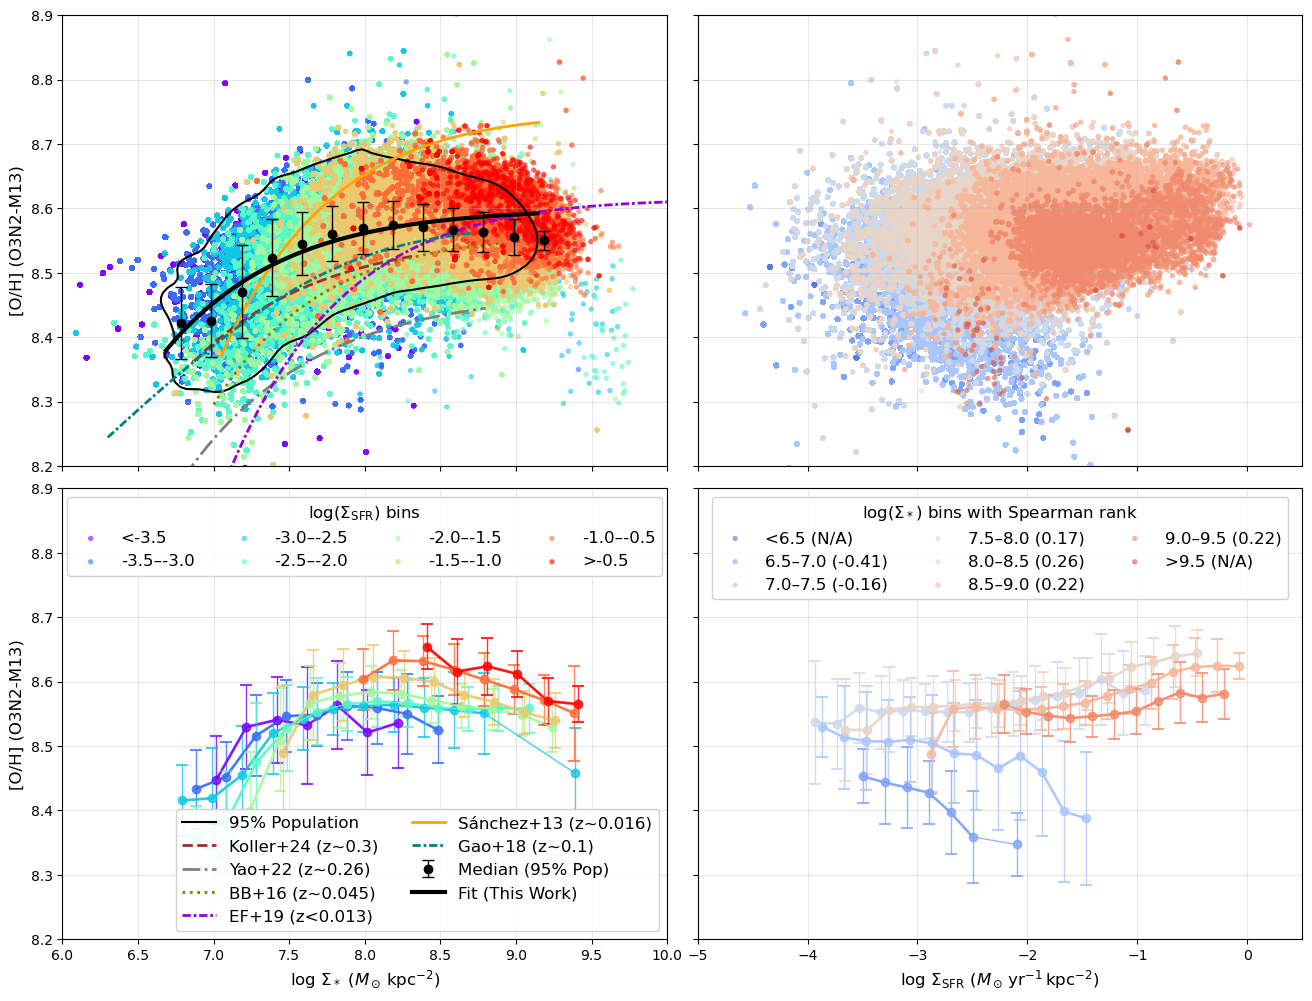


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # 5) Sánchez+13 (z ~ 0.016; CALIFA)
    # --------------------------------------------------------------
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.86, 0.97, 2.80
    a5, b5, c5 = 8.74, 0.013, 9.50    
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', '-', 'orange'))

    # --------------------------------------------------------------
    # 6) Gao+18: local Σ*-Z (MaNGA, 0.01<z<0.14, logM*:9.5-11)
    #    Here Σ_* is in Msun / kpc^2 already.
    #    They use a modified MZR-like form (Eq. 4).
    #    Below is a *generic* MZR-style form using their parameters
    #    (Z0, Σ_TO, γ, μ). Please replace with the exact Eq. (4).
    # --------------------------------------------------------------
    x_gao = np.linspace(6.3, 8.7, 200)  # log Σ_* [Msun/kpc^2]
    Sigma_gao = 10.0 ** x_gao

    # Published best-fit parameters (from their Table; double-check):
    Z0_G = 8.575      # asymptotic metallicity
    logSigma0_G = 7.738  # turnover Σ_* in Msun/kpc^2 (log10)
    gamma_G = 0.905
    mu_G = 0.250

    Sigma0_G = 10.0 ** logSigma0_G

    # Example MZR-style implementation:
    # 12+log(O/H) = Z0_G - mu_G * log10(1 + (Sigma0_G / Sigma_gao)^gamma_G)
    # REPLACE THIS WITH THE EXACT Gao+18 Eq. (4) FORM.
    y_gao18 = Z0_G - mu_G * np.log10(1.0 + (Sigma0_G / Sigma_gao) ** gamma_G)
    plot_data.append((x_gao, y_gao18, 'Gao+18', (0, (3, 1, 1, 1)), 'teal'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
 ]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
 ]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')
line_sanchez13 = plt.Line2D([0], [0], color='orange', linewidth=2, linestyle='-', label='Sánchez+13 (z~0.016)')
line_gao18 = plt.Line2D([0], [0], color='teal', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='Gao+18 (z~0.1)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.2, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    # Limit fit to min/max of 95% contour
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
    print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, line_sanchez13, line_gao18, median_95_err, fit_line]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Sánchez+13 (z~0.016)', 'Gao+18 (z~0.1)', 'Median (95% Pop)', 'Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        # legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        spearman_text = "N/A"
        
        if len(sfr_centers_HII) > 1:
            # Calculate Spearman correlation with 3-sigma clipping
            # Clip based on Y (Metallicity) and X (SFR)
            # Calculate mean and std for clipping
            y_mean = np.nanmean(y_bin_HII)
            y_std = np.nanstd(y_bin_HII)
            x_mean = np.nanmean(x_bin_HII)
            x_std = np.nanstd(x_bin_HII)
            
            # Create mask for 3-sigma clipping
            mask_clip = (np.abs(y_bin_HII - y_mean) < 3 * y_std) & \
                        (np.abs(x_bin_HII - x_mean) < 3 * x_std)
            
            x_clipped = x_bin_HII[mask_clip]
            y_clipped = y_bin_HII[mask_clip]
            
            if len(x_clipped) > 10:
                corr, _ = stats.spearmanr(x_clipped, y_clipped)
                spearman_text = f"{corr:.2f}"

            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1
            
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=3, fontsize=12, framealpha=0.9,
                     title=r'$\log(\Sigma_*)$ bins with Spearman rank', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3

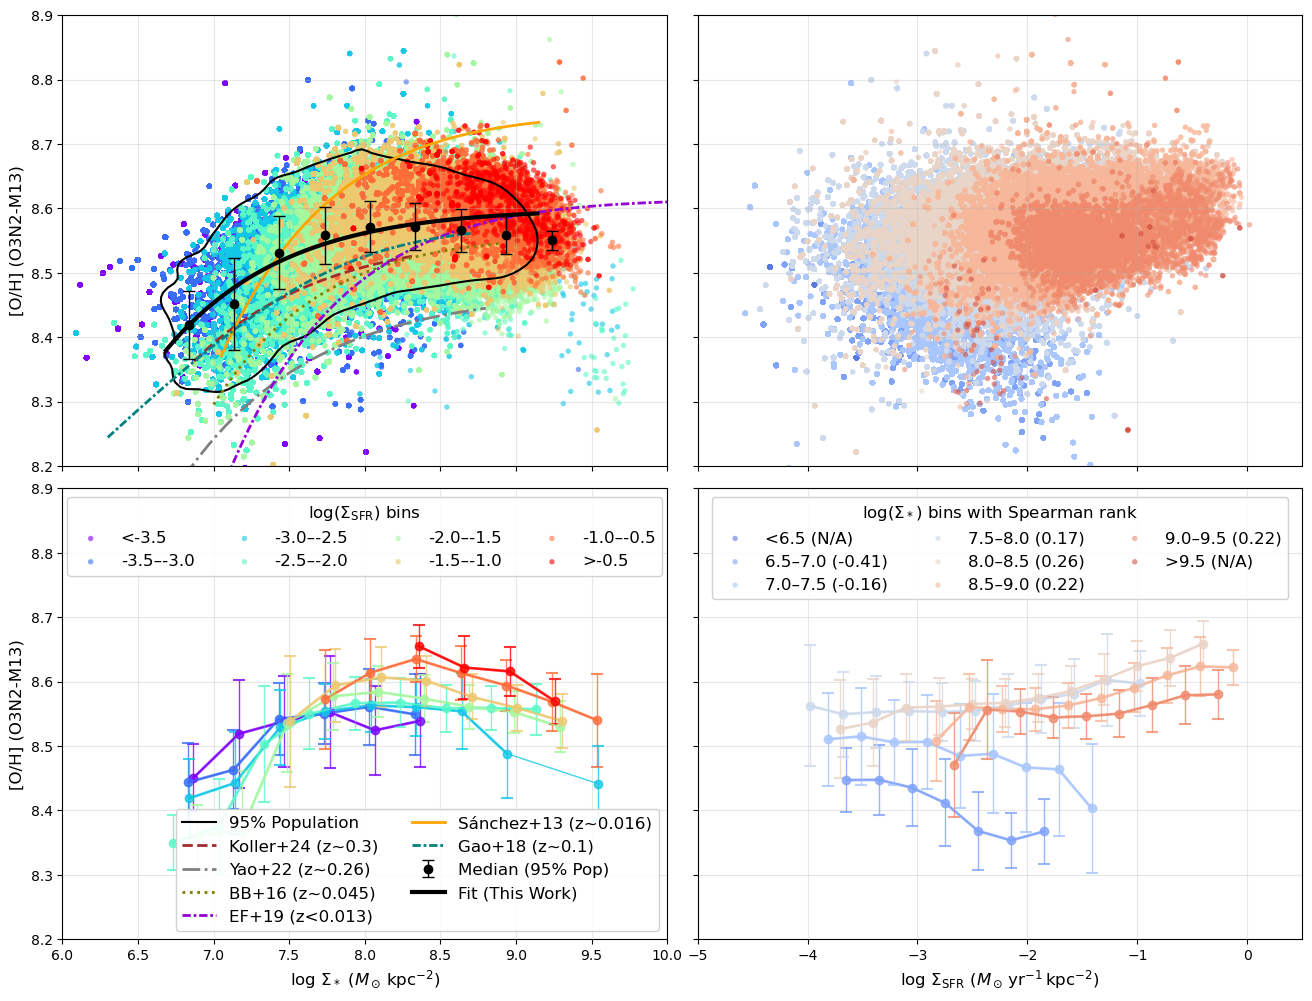


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [2]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.3, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # 5) Sánchez+13 (z ~ 0.016; CALIFA)
    # --------------------------------------------------------------
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.86, 0.97, 2.80
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', '-', 'orange'))

    # --------------------------------------------------------------
    # 6) Gao+18: local Σ*-Z (MaNGA, 0.01<z<0.14, logM*:9.5-11)
    #    Here Σ_* is in Msun / kpc^2 already.
    #    They use a modified MZR-like form (Eq. 4).
    #    Below is a *generic* MZR-style form using their parameters
    #    (Z0, Σ_TO, γ, μ). Please replace with the exact Eq. (4).
    # --------------------------------------------------------------
    x_gao = np.linspace(6.3, 8.7, 200)  # log Σ_* [Msun/kpc^2]
    Sigma_gao = 10.0 ** x_gao

    # Published best-fit parameters (from their Table; double-check):
    Z0_G = 8.575      # asymptotic metallicity
    logSigma0_G = 7.738  # turnover Σ_* in Msun/kpc^2 (log10)
    gamma_G = 0.905
    mu_G = 0.250

    Sigma0_G = 10.0 ** logSigma0_G

    # Example MZR-style implementation:
    # 12+log(O/H) = Z0_G - mu_G * log10(1 + (Sigma0_G / Sigma_gao)^gamma_G)
    # REPLACE THIS WITH THE EXACT Gao+18 Eq. (4) FORM.
    y_gao18 = Z0_G - mu_G * np.log10(1.0 + (Sigma0_G / Sigma_gao) ** gamma_G)
    plot_data.append((x_gao, y_gao18, 'Gao+18', (0, (3, 1, 1, 1)), 'teal'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
 ]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
 ]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.3, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')
line_sanchez13 = plt.Line2D([0], [0], color='orange', linewidth=2, linestyle='-', label='Sánchez+13 (z~0.016)')
line_gao18 = plt.Line2D([0], [0], color='teal', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='Gao+18 (z~0.1)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.3, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    # Limit fit to min/max of 95% contour
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
    print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, line_sanchez13, line_gao18, median_95_err, fit_line]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Sánchez+13 (z~0.016)', 'Gao+18 (z~0.1)', 'Median (95% Pop)', 'Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        # legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.3, min_pixels=20)
        
        spearman_text = "N/A"
        
        if len(sfr_centers_HII) > 1:
            # Calculate Spearman correlation with 3-sigma clipping
            # Clip based on Y (Metallicity) and X (SFR)
            # Calculate mean and std for clipping
            y_mean = np.nanmean(y_bin_HII)
            y_std = np.nanstd(y_bin_HII)
            x_mean = np.nanmean(x_bin_HII)
            x_std = np.nanstd(x_bin_HII)
            
            # Create mask for 3-sigma clipping
            mask_clip = (np.abs(y_bin_HII - y_mean) < 3 * y_std) & \
                        (np.abs(x_bin_HII - x_mean) < 3 * x_std)
            
            x_clipped = x_bin_HII[mask_clip]
            y_clipped = y_bin_HII[mask_clip]
            
            if len(x_clipped) > 10:
                corr, _ = stats.spearmanr(x_clipped, y_clipped)
                spearman_text = f"{corr:.2f}"

            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1
            
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=3, fontsize=12, framealpha=0.9,
                     title=r'$\log(\Sigma_*)$ bins with Spearman rank', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  B

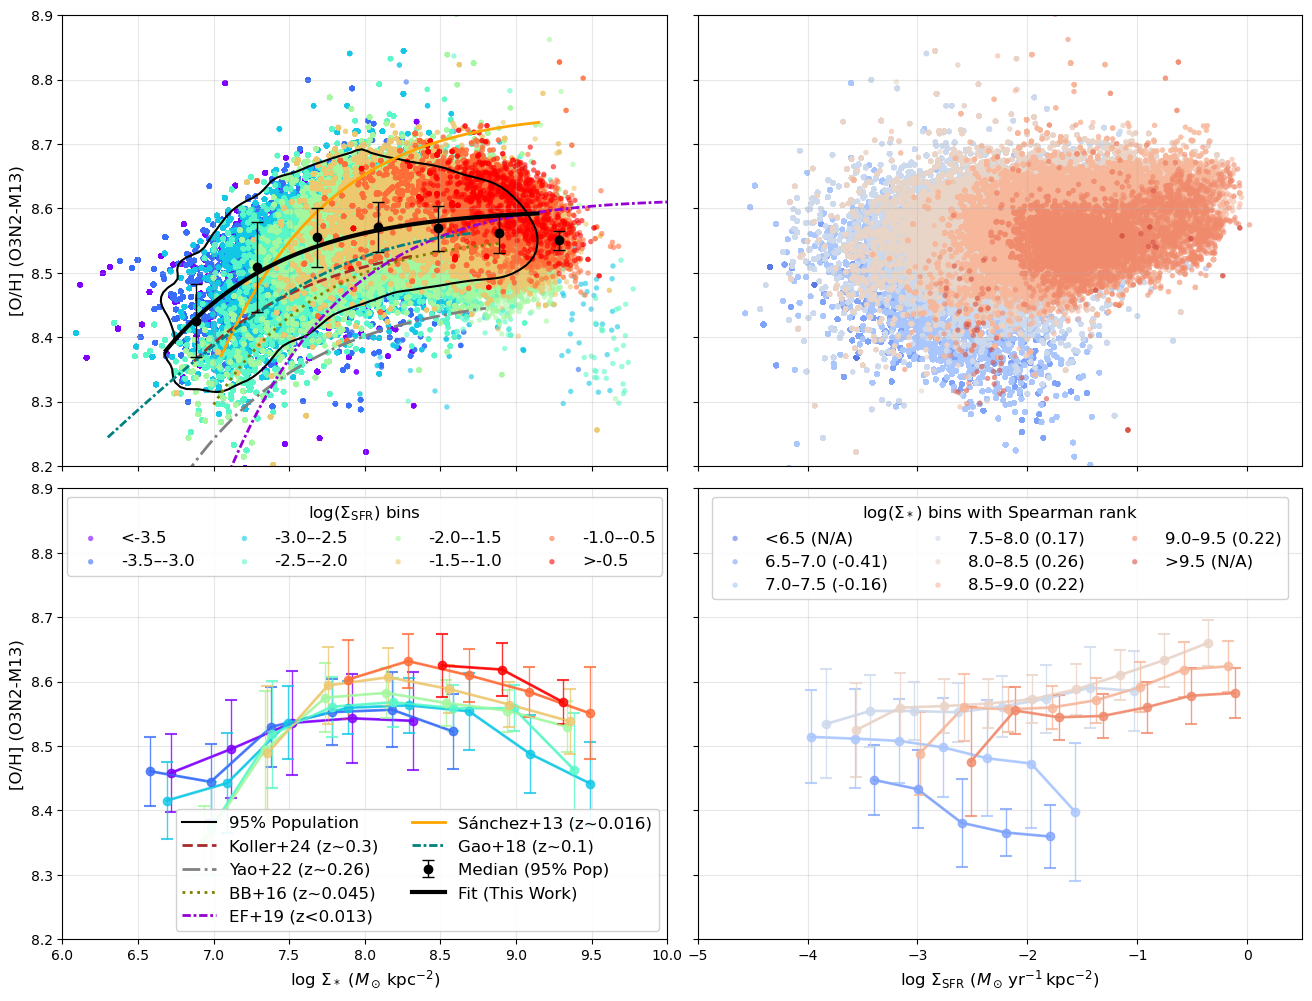


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [3]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # 5) Sánchez+13 (z ~ 0.016; CALIFA)
    # --------------------------------------------------------------
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.86, 0.97, 2.80
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', '-', 'orange'))

    # --------------------------------------------------------------
    # 6) Gao+18: local Σ*-Z (MaNGA, 0.01<z<0.14, logM*:9.5-11)
    #    Here Σ_* is in Msun / kpc^2 already.
    #    They use a modified MZR-like form (Eq. 4).
    #    Below is a *generic* MZR-style form using their parameters
    #    (Z0, Σ_TO, γ, μ). Please replace with the exact Eq. (4).
    # --------------------------------------------------------------
    x_gao = np.linspace(6.3, 8.7, 200)  # log Σ_* [Msun/kpc^2]
    Sigma_gao = 10.0 ** x_gao

    # Published best-fit parameters (from their Table; double-check):
    Z0_G = 8.575      # asymptotic metallicity
    logSigma0_G = 7.738  # turnover Σ_* in Msun/kpc^2 (log10)
    gamma_G = 0.905
    mu_G = 0.250

    Sigma0_G = 10.0 ** logSigma0_G

    # Example MZR-style implementation:
    # 12+log(O/H) = Z0_G - mu_G * log10(1 + (Sigma0_G / Sigma_gao)^gamma_G)
    # REPLACE THIS WITH THE EXACT Gao+18 Eq. (4) FORM.
    y_gao18 = Z0_G - mu_G * np.log10(1.0 + (Sigma0_G / Sigma_gao) ** gamma_G)
    plot_data.append((x_gao, y_gao18, 'Gao+18', (0, (3, 1, 1, 1)), 'teal'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
 ]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
 ]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.4, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')
line_sanchez13 = plt.Line2D([0], [0], color='orange', linewidth=2, linestyle='-', label='Sánchez+13 (z~0.016)')
line_gao18 = plt.Line2D([0], [0], color='teal', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='Gao+18 (z~0.1)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.4, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    # Limit fit to min/max of 95% contour
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
    print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, line_sanchez13, line_gao18, median_95_err, fit_line]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Sánchez+13 (z~0.016)', 'Gao+18 (z~0.1)', 'Median (95% Pop)', 'Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        # legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.4, min_pixels=20)
        
        spearman_text = "N/A"
        
        if len(sfr_centers_HII) > 1:
            # Calculate Spearman correlation with 3-sigma clipping
            # Clip based on Y (Metallicity) and X (SFR)
            # Calculate mean and std for clipping
            y_mean = np.nanmean(y_bin_HII)
            y_std = np.nanstd(y_bin_HII)
            x_mean = np.nanmean(x_bin_HII)
            x_std = np.nanstd(x_bin_HII)
            
            # Create mask for 3-sigma clipping
            mask_clip = (np.abs(y_bin_HII - y_mean) < 3 * y_std) & \
                        (np.abs(x_bin_HII - x_mean) < 3 * x_std)
            
            x_clipped = x_bin_HII[mask_clip]
            y_clipped = y_bin_HII[mask_clip]
            
            if len(x_clipped) > 10:
                corr, _ = stats.spearmanr(x_clipped, y_clipped)
                spearman_text = f"{corr:.2f}"

            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1
            
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=3, fontsize=12, framealpha=0.9,
                     title=r'$\log(\Sigma_*)$ bins with Spearman rank', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  B

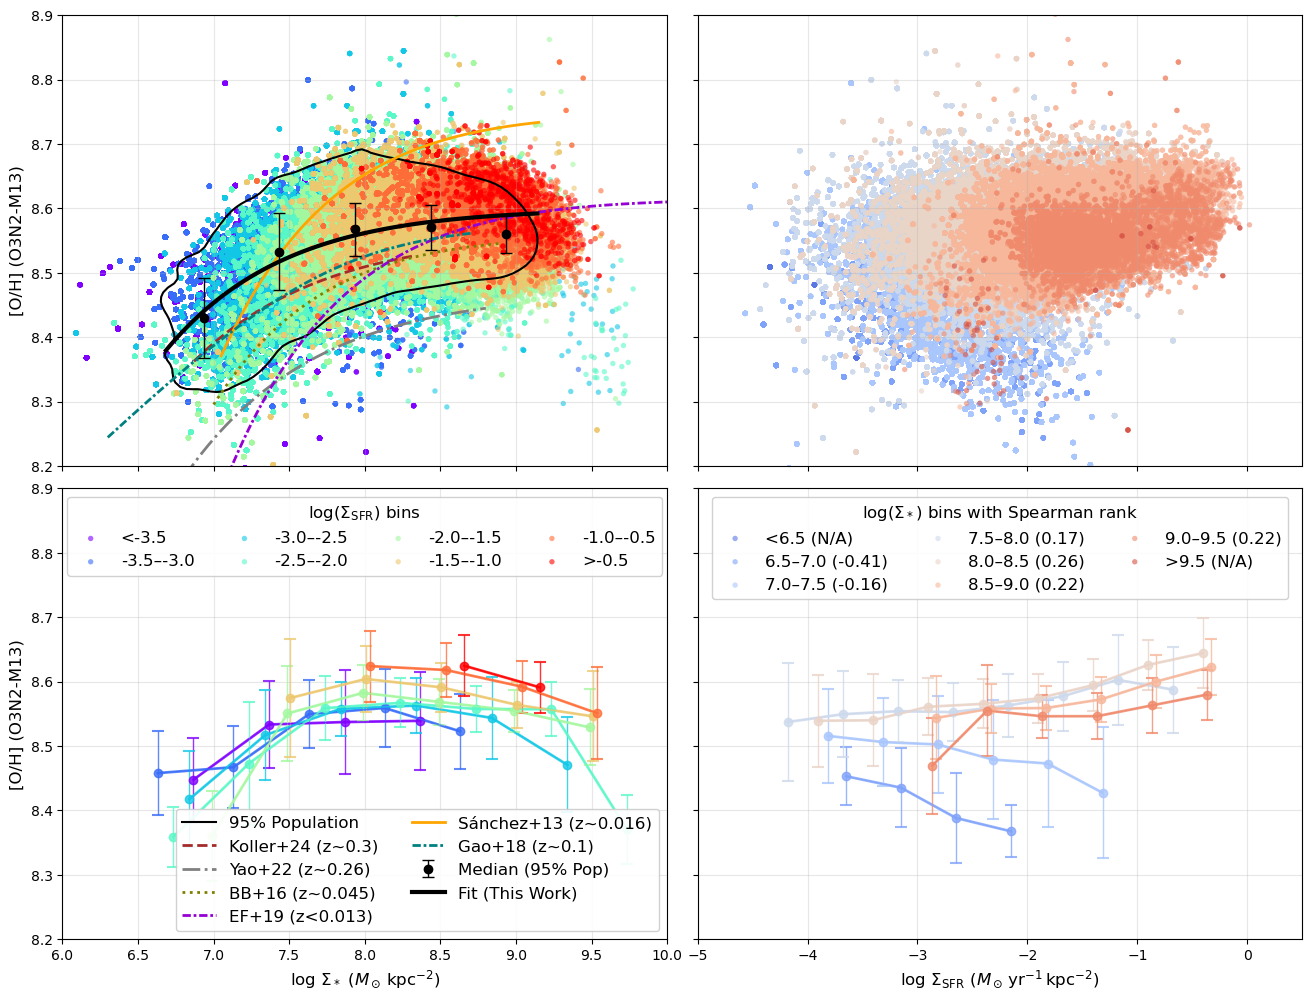


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [4]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.5, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # 5) Sánchez+13 (z ~ 0.016; CALIFA)
    # --------------------------------------------------------------
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.86, 0.97, 2.80
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', '-', 'orange'))

    # --------------------------------------------------------------
    # 6) Gao+18: local Σ*-Z (MaNGA, 0.01<z<0.14, logM*:9.5-11)
    #    Here Σ_* is in Msun / kpc^2 already.
    #    They use a modified MZR-like form (Eq. 4).
    #    Below is a *generic* MZR-style form using their parameters
    #    (Z0, Σ_TO, γ, μ). Please replace with the exact Eq. (4).
    # --------------------------------------------------------------
    x_gao = np.linspace(6.3, 8.7, 200)  # log Σ_* [Msun/kpc^2]
    Sigma_gao = 10.0 ** x_gao

    # Published best-fit parameters (from their Table; double-check):
    Z0_G = 8.575      # asymptotic metallicity
    logSigma0_G = 7.738  # turnover Σ_* in Msun/kpc^2 (log10)
    gamma_G = 0.905
    mu_G = 0.250

    Sigma0_G = 10.0 ** logSigma0_G

    # Example MZR-style implementation:
    # 12+log(O/H) = Z0_G - mu_G * log10(1 + (Sigma0_G / Sigma_gao)^gamma_G)
    # REPLACE THIS WITH THE EXACT Gao+18 Eq. (4) FORM.
    y_gao18 = Z0_G - mu_G * np.log10(1.0 + (Sigma0_G / Sigma_gao) ** gamma_G)
    plot_data.append((x_gao, y_gao18, 'Gao+18', (0, (3, 1, 1, 1)), 'teal'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
 ]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
 ]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.5, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')
line_sanchez13 = plt.Line2D([0], [0], color='orange', linewidth=2, linestyle='-', label='Sánchez+13 (z~0.016)')
line_gao18 = plt.Line2D([0], [0], color='teal', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='Gao+18 (z~0.1)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.5, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    # Limit fit to min/max of 95% contour
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
    print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, line_sanchez13, line_gao18, median_95_err, fit_line]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Sánchez+13 (z~0.016)', 'Gao+18 (z~0.1)', 'Median (95% Pop)', 'Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        # legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.5, min_pixels=20)
        
        spearman_text = "N/A"
        
        if len(sfr_centers_HII) > 1:
            # Calculate Spearman correlation with 3-sigma clipping
            # Clip based on Y (Metallicity) and X (SFR)
            # Calculate mean and std for clipping
            y_mean = np.nanmean(y_bin_HII)
            y_std = np.nanstd(y_bin_HII)
            x_mean = np.nanmean(x_bin_HII)
            x_std = np.nanstd(x_bin_HII)
            
            # Create mask for 3-sigma clipping
            mask_clip = (np.abs(y_bin_HII - y_mean) < 3 * y_std) & \
                        (np.abs(x_bin_HII - x_mean) < 3 * x_std)
            
            x_clipped = x_bin_HII[mask_clip]
            y_clipped = y_bin_HII[mask_clip]
            
            if len(x_clipped) > 10:
                corr, _ = stats.spearmanr(x_clipped, y_clipped)
                spearman_text = f"{corr:.2f}"

            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1
            
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=3, fontsize=12, framealpha=0.9,
                     title=r'$\log(\Sigma_*)$ bins with Spearman rank', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

## 20251208 3$\sigma$ clip instead of 95% contour

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3

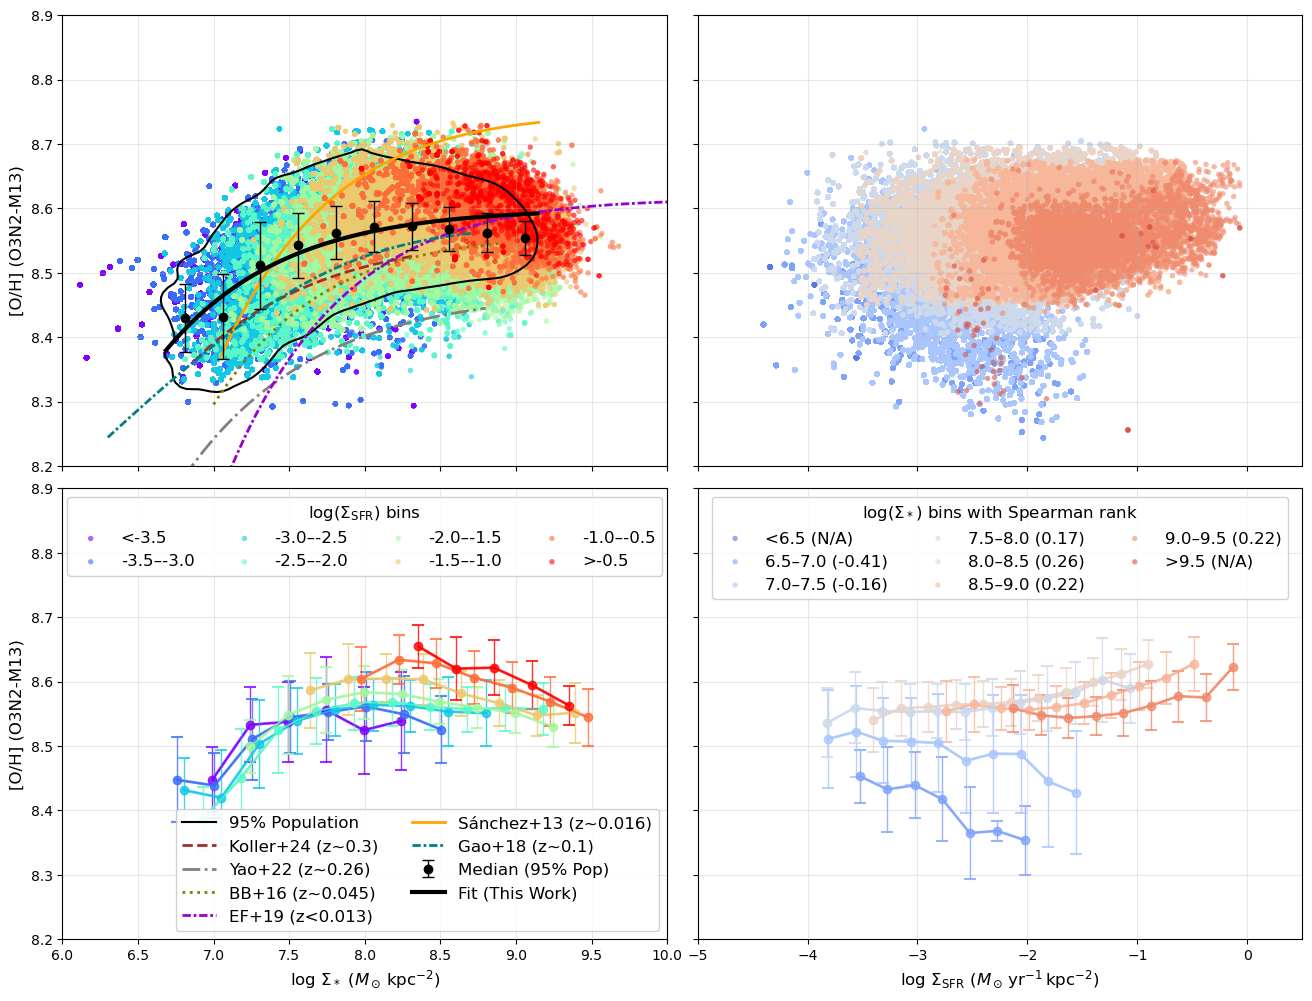


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis with 3-sigma clipping (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins) with 3-sigma clipping
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins) with 3-sigma clipping
  Bottom-left: rMZR median trends (8 Σ_SFR bins) with 3-sigma clipping
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins) with 3-sigma clipping
  Shared y-range: 8.2 to 8.9


In [5]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# Added: 3-sigma clipping in binned stats
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.25, min_pixels=20):
    """Calculate median and std in bins with 3-sigma clipping for Spearman calc"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        # Only keep if enough pixels
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # 5) Sánchez+13 (z ~ 0.016; CALIFA)
    # --------------------------------------------------------------
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.86, 0.97, 2.80
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', '-', 'orange'))

    # --------------------------------------------------------------
    # 6) Gao+18: local Σ*-Z (MaNGA, 0.01<z<0.14, logM*:9.5-11)
    #    Here Σ_* is in Msun / kpc^2 already.
    #    They use a modified MZR-like form (Eq. 4).
    #    Below is a *generic* MZR-style form using their parameters
    #    (Z0, Σ_TO, γ, μ). Please replace with the exact Eq. (4).
    # --------------------------------------------------------------
    x_gao = np.linspace(6.3, 8.7, 200)  # log Σ_* [Msun/kpc^2]
    Sigma_gao = 10.0 ** x_gao

    # Published best-fit parameters (from their Table; double-check):
    Z0_G = 8.575      # asymptotic metallicity
    logSigma0_G = 7.738  # turnover Σ_* in Msun/kpc^2 (log10)
    gamma_G = 0.905
    mu_G = 0.250

    Sigma0_G = 10.0 ** logSigma0_G

    # Example MZR-style implementation:
    # 12+log(O/H) = Z0_G - mu_G * log10(1 + (Sigma0_G / Sigma_gao)^gamma_G)
    # REPLACE THIS WITH THE EXACT Gao+18 Eq. (4) FORM.
    y_gao18 = Z0_G - mu_G * np.log10(1.0 + (Sigma0_G / Sigma_gao) ** gamma_G)
    plot_data.append((x_gao, y_gao18, 'Gao+18', (0, (3, 1, 1, 1)), 'teal'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
 ]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
 ]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # 3-sigma clipping within bin for Spearman
        y_mean = np.nanmean(y_bin_HII)
        y_std = np.nanstd(y_bin_HII)
        x_mean = np.nanmean(x_bin_HII)
        x_std = np.nanstd(x_bin_HII)
        mask_clip = (np.abs(y_bin_HII - y_mean) < 3 * y_std) & (np.abs(x_bin_HII - x_mean) < 3 * x_std)
        
        y_bin_HII_clipped = y_bin_HII[mask_clip]
        x_bin_HII_clipped = x_bin_HII[mask_clip]
        
        # Scatter plot with clipped data
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII_clipped, y_bin_HII_clipped, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII_clipped, y_bin_HII_clipped, bin_width=0.25, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')
line_sanchez13 = plt.Line2D([0], [0], color='orange', linewidth=2, linestyle='-', label='Sánchez+13 (z~0.016)')
line_gao18 = plt.Line2D([0], [0], color='teal', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='Gao+18 (z~0.1)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.25, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    # Limit fit to min/max of 95% contour
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
    print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, line_sanchez13, line_gao18, median_95_err, fit_line]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Sánchez+13 (z~0.016)', 'Gao+18 (z~0.1)', 'Median (95% Pop)', 'Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # 3-sigma clipping within bin for Spearman
        y_mean = np.nanmean(y_bin_HII)
        y_std = np.nanstd(y_bin_HII)
        x_mean = np.nanmean(x_bin_HII)
        x_std = np.nanstd(x_bin_HII)
        mask_clip = (np.abs(y_bin_HII - y_mean) < 3 * y_std) & (np.abs(x_bin_HII - x_mean) < 3 * x_std)
        
        y_bin_HII_clipped = y_bin_HII[mask_clip]
        x_bin_HII_clipped = x_bin_HII[mask_clip]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII_clipped, y_bin_HII_clipped, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII_clipped, y_bin_HII_clipped, bin_width=0.25, min_pixels=20)
        
        spearman_text = "N/A"
        
        if len(sfr_centers_HII) > 1:
            # Calculate Spearman correlation with 3-sigma clipping
            corr, _ = stats.spearmanr(x_bin_HII_clipped, y_bin_HII_clipped)
            spearman_text = f"{corr:.2f}"

            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1
            
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=3, fontsize=12, framealpha=0.9,
                     title=r'$\log(\Sigma_*)$ bins with Spearman rank', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_clip.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_clip.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis with 3-sigma clipping (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins) with 3-sigma clipping")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins) with 3-sigma clipping")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins) with 3-sigma clipping")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins) with 3-sigma clipping")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

## 20251208 ODR fitting instead of curve_fit

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–

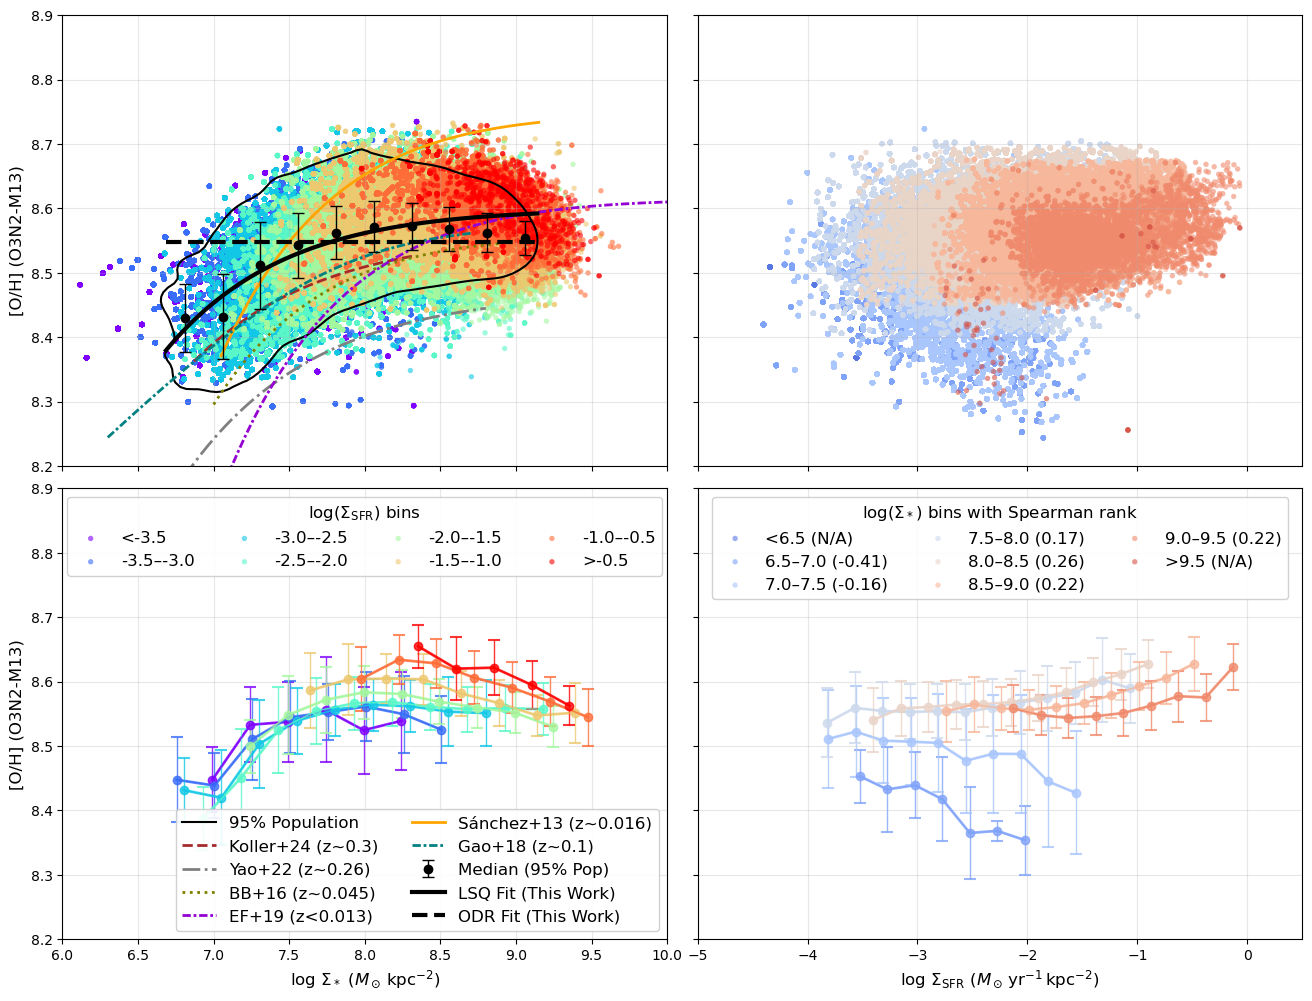


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis with ODR fit (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins) with ODR fitting
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins) with ODR fitting
  Bottom-left: rMZR median trends (8 Σ_SFR bins) with ODR fitting
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins) with ODR fitting
  Shared y-range: 8.2 to 8.9


In [6]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# Added: ODR fitting in rMZR
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit
from scipy import odr

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.25, min_pixels=20):
    """Calculate median and std in bins with 3-sigma clipping"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def odr_mzr(beta, x):
    a, b, c = beta
    return a + b * (x - c) * np.exp(-(x - c))

def run_odr_fit(x, y, xerr=None, yerr=None, beta0=(8.5, 0.0002, 12.5)):
    """Run Orthogonal Distance Regression on mzr_model."""
    if xerr is None:
        xerr = np.ones_like(x) * 0.1
    if yerr is None:
        yerr = np.ones_like(y) * 0.05
    
    data = odr.RealData(x, y, sx=xerr, sy=yerr)
    model = odr.Model(odr_mzr)
    myodr = odr.ODR(data, model, beta0=beta0, maxit=10000)
    out = myodr.run()
    return out

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # 5) Sánchez+13 (z ~ 0.016; CALIFA)
    # --------------------------------------------------------------
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.86, 0.97, 2.80
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', '-', 'orange'))

    # --------------------------------------------------------------
    # 6) Gao+18: local Σ*-Z (MaNGA, 0.01<z<0.14, logM*:9.5-11)
    #    Here Σ_* is in Msun / kpc^2 already.
    #    They use a modified MZR-like form (Eq. 4).
    #    Below is a *generic* MZR-style form using their parameters
    #    (Z0, Σ_TO, γ, μ). Please replace with the exact Eq. (4).
    # --------------------------------------------------------------
    x_gao = np.linspace(6.3, 8.7, 200)  # log Σ_* [Msun/kpc^2]
    Sigma_gao = 10.0 ** x_gao

    # Published best-fit parameters (from their Table; double-check):
    Z0_G = 8.575      # asymptotic metallicity
    logSigma0_G = 7.738  # turnover Σ_* in Msun/kpc^2 (log10)
    gamma_G = 0.905
    mu_G = 0.250

    Sigma0_G = 10.0 ** logSigma0_G

    # Example MZR-style implementation:
    # 12+log(O/H) = Z0_G - mu_G * log10(1 + (Sigma0_G / Sigma_gao)^gamma_G)
    # REPLACE THIS WITH THE EXACT Gao+18 Eq. (4) FORM.
    y_gao18 = Z0_G - mu_G * np.log10(1.0 + (Sigma0_G / Sigma_gao) ** gamma_G)
    plot_data.append((x_gao, y_gao18, 'Gao+18', (0, (3, 1, 1, 1)), 'teal'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
 ]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
 ]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # 3-sigma clipping within bin
        y_mean = np.nanmean(y_bin_HII)
        y_std = np.nanstd(y_bin_HII)
        x_mean = np.nanmean(x_bin_HII)
        x_std = np.nanstd(x_bin_HII)
        mask_clip = (np.abs(y_bin_HII - y_mean) < 3 * y_std) & (np.abs(x_bin_HII - x_mean) < 3 * x_std)
        
        y_bin_HII_clipped = y_bin_HII[mask_clip]
        x_bin_HII_clipped = x_bin_HII[mask_clip]
        
        # Scatter plot with clipped data
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII_clipped, y_bin_HII_clipped, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII_clipped, y_bin_HII_clipped, bin_width=0.25, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')
line_sanchez13 = plt.Line2D([0], [0], color='orange', linewidth=2, linestyle='-', label='Sánchez+13 (z~0.016)')
line_gao18 = plt.Line2D([0], [0], color='teal', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='Gao+18 (z~0.1)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.25, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data (least squares)
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='LSQ Fit (This Work)')
    print(f"LSQ fit: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Least-squares fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='LSQ Fit (Failed)')

# 6. ODR fit (orthogonal)
try:
    odr_out = run_odr_fit(x_95, y_95, beta0=p0)
    x_fit_odr = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit_odr = mzr_model(x_fit_odr, *odr_out.beta)
    fit_line_odr, = ax_rMZR_scatter.plot(x_fit_odr, y_fit_odr, 'k--', linewidth=3, label='ODR Fit (This Work)')
    print(f"ODR fit: a={odr_out.beta[0]:.3f}, b={odr_out.beta[1]:.5f}, c={odr_out.beta[2]:.3f}")
except Exception as e:
    print(f"ODR fitting failed: {e}")
    fit_line_odr = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='--', label='ODR Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, line_sanchez13, line_gao18, median_95_err, fit_line, fit_line_odr]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Sánchez+13 (z~0.016)', 'Gao+18 (z~0.1)', 'Median (95% Pop)', 'LSQ Fit (This Work)', 'ODR Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # 3-sigma clipping within bin
        y_mean = np.nanmean(y_bin_HII)
        y_std = np.nanstd(y_bin_HII)
        x_mean = np.nanmean(x_bin_HII)
        x_std = np.nanstd(x_bin_HII)
        mask_clip = (np.abs(y_bin_HII - y_mean) < 3 * y_std) & (np.abs(x_bin_HII - x_mean) < 3 * x_std)
        
        y_bin_HII_clipped = y_bin_HII[mask_clip]
        x_bin_HII_clipped = x_bin_HII[mask_clip]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII_clipped, y_bin_HII_clipped, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII_clipped, y_bin_HII_clipped, bin_width=0.25, min_pixels=20)
        
        spearman_text = "N/A"
        
        if len(sfr_centers_HII) > 1:
            # Calculate Spearman correlation with 3-sigma clipping
            corr, _ = stats.spearmanr(x_bin_HII_clipped, y_bin_HII_clipped)
            spearman_text = f"{corr:.2f}"

            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1
            
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=3, fontsize=12, framealpha=0.9,
                     title=r'$\log(\Sigma_*)$ bins with Spearman rank', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_ODR.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_ODR.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis with ODR fit (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins) with ODR fitting")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins) with ODR fitting")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins) with ODR fitting")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins) with ODR fitting")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

## 20121208 use C20 and compare with Baker+2023


STEP 1: Collecting data from all galaxies for HII regions (C20 + M13)
  IC3392: HII=14884 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

Using uniform y-axis range: 8.4 to 9.1
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

Using uniform y-axis rang

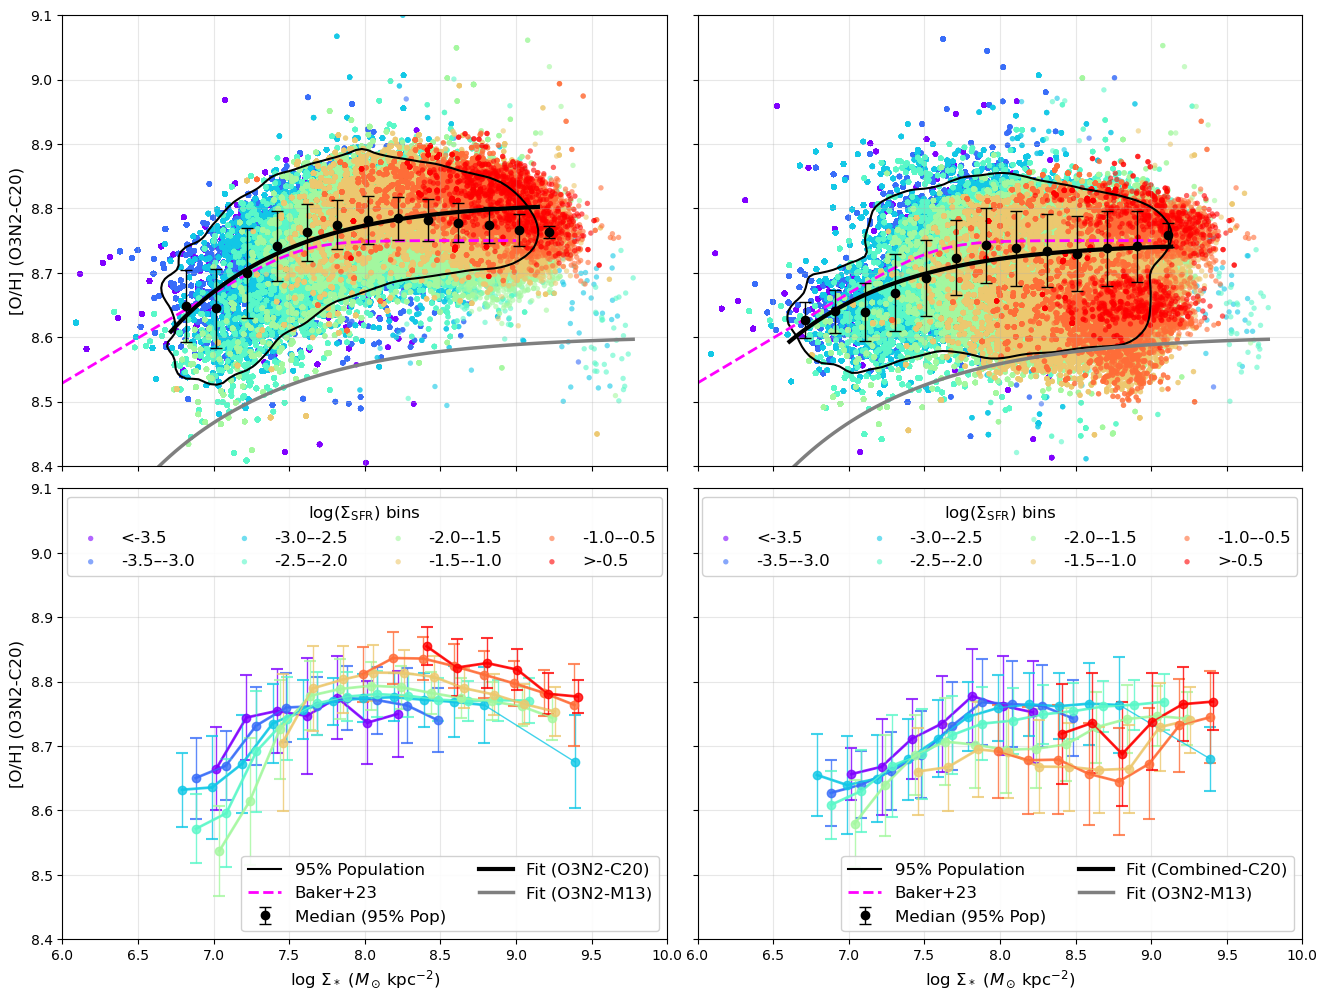

In [7]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR comparison between O3N2-C20 and Combined-C20
# HII regions only; left column uses O3N2-C20, right column mirrors rMZR
# but with Combined-C20. Literature overlay reduced to Baker+23 only.
# Also overlays our best-fit curve from O3N2-M13 for reference.
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit


def load_maps(gal):
    """Load Σ*, Σ_SFR and multiple metallicity calibrations for HII regions."""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h_bin:
        sigM = h_bin["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h_gas:
        sigSFR_HII = h_gas["LOGSFR_SURFACE_DENSITY_HII"].data
        oh_o3n2_m13_HII = h_gas["O_H_O3N2_M13_HII"].data
        oh_o3n2_c20_HII = h_gas["O_H_O3N2_C20_HII"].data
        oh_combined_c20_HII = h_gas["O_H_Combined_C20_HII"].data
    return sigM, sigSFR_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII, oh_combined_c20_HII


def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with enough unique points."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)

    return (
        np.array(valid_centers),
        np.array(medians),
        np.array(stds),
        np.array(counts),
        np.array(valid_bin_indices),
    )


def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))


def plot_literature_baker(ax, show_legend=True):
    """Overlay Baker+23 collapsed rFMR curve."""
    plot_data = []

    # --------------------------------------------------------------
    # 7) Baker+23: MaNGA rFMR collapsed to a 1D rMZR track
    #     Use Eq. (7) with combined-sample parameters (Table 2).
    # --------------------------------------------------------------
    x_baker = np.linspace(6.0, 9.0, 200)          # log Σ_*  [M⊙ kpc^-2]
    logSigmaSFR_ref = -2.0                        # M⊙ yr^-1 kpc^-2 (adjust if desired)

    Z0_B   = 8.75
    gamma_B = 0.14
    phi_B   = 2.73
    m0_B    = 8.58
    m1_B    = 0.50

    logM0_B = m0_B + m1_B * logSigmaSFR_ref
    M0_B    = 10.0 ** logM0_B

    Sigma_star_B = 10.0 ** x_baker
    y_baker23 = Z0_B - (gamma_B / phi_B) * np.log10(
        1.0 + (Sigma_star_B / M0_B) ** (-phi_B)
    )

    plot_data.append((x_baker, y_baker23, "Baker+23", "--", "magenta"))

    for x, y, label, linestyle, color in plot_data:
        ax.plot(x, y, label=label if show_legend else None, linewidth=2,
                linestyle=linestyle, color=color)


# ------------------------------------------------------------------
# Data ingestion
# ------------------------------------------------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]

excluded_galaxies = {"NGC4383"}
included_galaxies = []

all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []
all_oh_combined_c20_HII = []

print("=" * 80)
print("STEP 1: Collecting data from all galaxies for HII regions (C20 + M13)")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (
            logSigmaM,
            logSigmaSFR_HII,
            oh_o3n2_m13_HII,
            oh_o3n2_c20_HII,
            oh_combined_c20_HII,
        ) = load_maps(gal)

        common_mask_HII = (
            np.isfinite(logSigmaM)
            & np.isfinite(logSigmaSFR_HII)
            & np.isfinite(oh_o3n2_c20_HII)
            & np.isfinite(oh_combined_c20_HII)
        )

        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")

        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        all_oh_combined_c20_HII.extend(oh_combined_c20_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)
all_oh_combined_c20_HII = np.array(all_oh_combined_c20_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ------------------------------------------------------------------
# Bin definitions
# ------------------------------------------------------------------
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ["<-3.5", "-3.5–-3.0", "-3.0–-2.5", "-2.5–-2.0", "-2.0–-1.5", "-1.5–-1.0", "-1.0–-0.5", ">-0.5"]
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ["<6.5", "6.5–7.0", "7.0–7.5", "7.5–8.0", "8.0–8.5", "8.5–9.0", "9.0–9.5", ">9.5"]
colors_sigmaM = plt.cm.rainbow(np.linspace(0, 1, n_bins_sigmaM))

# ------------------------------------------------------------------
# Plot setup
# ------------------------------------------------------------------
common_ylim = (8.4, 9.1)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex="col", sharey="all")
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Axis assignment
ax_rMZR_scatter = axes[0, 0]
ax_rMZR_median = axes[1, 0]
ax_rMZR_scatter_right = axes[0, 1]
ax_rMZR_median_right = axes[1, 1]

# Helper to build rMZR panel

def process_rMZR(ax_scatter, ax_median, oh_data_HII, calib_name_HII, color_palette):
    print(f"\n--- Processing rMZR ({calib_name_HII}) ---")
    legend_handles_sfr_local = []
    legend_labels_sfr_local = []

    valid_bins = 0
    for i in range(n_bins):
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
        n_pixels_HII = np.sum(in_bin_HII)
        if n_pixels_HII >= 10:
            x_bin = all_logSigmaM_HII[in_bin_HII]
            y_bin = oh_data_HII[in_bin_HII]

            scatter_hii = ax_scatter.scatter(
                x_bin, y_bin, c=[color_palette[i]], s=15, alpha=0.6, edgecolors="none", rasterized=True
            )
            legend_handles_sfr_local.append(scatter_hii)
            legend_labels_sfr_local.append(bin_labels[i])

            mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats(x_bin, y_bin, bin_width=0.2, min_pixels=20)
            if len(mass_centers) > 0:
                ax_median.errorbar(
                    mass_centers,
                    medians,
                    yerr=stds,
                    color=color_palette[i],
                    marker="o",
                    markersize=6,
                    linewidth=1,
                    capsize=4,
                    capthick=1.5,
                    alpha=0.8,
                )

                for j in range(len(valid_idx) - 1):
                    current_bin_idx = valid_idx[j]
                    next_bin_idx = valid_idx[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_median.plot(
                            [mass_centers[j], mass_centers[j + 1]],
                            [medians[j], medians[j + 1]],
                            color=color_palette[i],
                            linewidth=2,
                            alpha=0.8,
                        )
                valid_bins += 1

    x_data = all_logSigmaM_HII
    y_data = oh_data_HII
    mask = np.isfinite(x_data) & np.isfinite(y_data)
    x_clean = x_data[mask]
    y_clean = y_data[mask]

    xmin, xmax = 6, 10
    ymin, ymax = common_ylim
    nbins = 100
    H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
    sigma = 2.0
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_sum = np.sum(H_flat)
    H_cumsum = np.cumsum(H_flat)
    idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
    level_95 = H_flat[idx_95]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    ax_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors="k", linewidths=1.5, linestyles="-")
    contour_line = plt.Line2D([0], [0], color="k", linewidth=1.5, linestyle="-", label="95% Population")

    plot_literature_baker(ax_scatter, show_legend=False)
    line_baker = plt.Line2D([0], [0], color="magenta", linewidth=2, linestyle="--", label="Baker+23")

    dx = (xmax - xmin) / nbins
    dy = (ymax - ymin) / nbins
    x_idx = (x_clean - xmin) / dx - 0.5
    y_idx = (y_clean - ymin) / dy - 0.5
    point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0)
    mask_95 = point_densities >= level_95
    x_95 = x_clean[mask_95]
    y_95 = y_clean[mask_95]
    mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
        x_95, y_95, bin_width=0.2, min_pixels=20
    )
    median_95_err = ax_scatter.errorbar(
        mass_centers_95,
        medians_95,
        yerr=stds_95,
        fmt="o",
        color="k",
        markersize=6,
        linewidth=1,
        capsize=4,
        label="Median (95% Pop)",
    )

    p0 = [8.5, 0.0002, 12.5]
    bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
    try:
        popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
        x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
        y_fit = mzr_model(x_fit, *popt)
        fit_line, = ax_scatter.plot(x_fit, y_fit, "k-", linewidth=3, label=f"Fit ({calib_name_HII})")
        print(f"Fit {calib_name_HII}: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
    except Exception as e:
        print(f"Fitting failed for {calib_name_HII}: {e}")
        fit_line = plt.Line2D([0], [0], color="k", linewidth=3, linestyle="-", label=f"Fit ({calib_name_HII})")

    try:
        mask_m13 = np.isfinite(all_oh_o3n2_m13_HII)
        x_m13 = all_logSigmaM_HII[mask_m13]
        y_m13 = all_oh_o3n2_m13_HII[mask_m13]
        popt_m13, _ = curve_fit(mzr_model, x_m13, y_m13, p0=p0, bounds=bounds, maxfev=5000)
        x_fit_m13 = np.linspace(np.min(x_m13), np.max(x_m13), 100)
        y_fit_m13 = mzr_model(x_fit_m13, *popt_m13)
        fit_line_m13, = ax_scatter.plot(x_fit_m13, y_fit_m13, "C7-", linewidth=2.5, label="Fit (O3N2-M13)")
        print(f"Fit O3N2-M13: a={popt_m13[0]:.3f}, b={popt_m13[1]:.5f}, c={popt_m13[2]:.3f}")
    except Exception as e:
        print(f"Fitting failed for O3N2-M13: {e}")
        fit_line_m13 = plt.Line2D([0], [0], color="C7", linewidth=2.5, linestyle="-", label="Fit (O3N2-M13)")

    ax_scatter.set_ylabel(f"[O/H] ({calib_name_HII})", fontsize=12)
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.set_xlim(6, 10)
    ax_scatter.set_ylim(common_ylim)

    ax_median.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
    ax_median.set_ylabel(f"[O/H] ({calib_name_HII})", fontsize=12)
    ax_median.grid(True, alpha=0.3)
    ax_median.set_xlim(6, 10)
    ax_median.set_ylim(common_ylim)

    legend1 = ax_median.legend(
        legend_handles_sfr_local,
        legend_labels_sfr_local,
        loc="upper center",
        ncol=4,
        fontsize=12,
        framealpha=0.9,
        title=r"$\log(\Sigma_\mathrm{SFR})$ bins",
        title_fontsize=12,
    )
    ax_median.add_artist(legend1)

    handles_bl = [contour_line, line_baker, median_95_err, fit_line, fit_line_m13]
    labels_bl = ["95% Population", "Baker+23", "Median (95% Pop)", f"Fit ({calib_name_HII})", "Fit (O3N2-M13)"]
    ax_median.legend(handles_bl, labels_bl, loc="lower right", ncol=2, fontsize=12, framealpha=0.9)

    print(f"  rMZR valid bins ({calib_name_HII}): {valid_bins}")


# Left column: O3N2-C20
process_rMZR(ax_rMZR_scatter, ax_rMZR_median, all_oh_o3n2_c20_HII, "O3N2-C20", colors_sfr)

# Right column: Combined-C20 (mirror rMZR layout)
process_rMZR(ax_rMZR_scatter_right, ax_rMZR_median_right, all_oh_combined_c20_HII, "Combined-C20", colors_sigmaM)

# Shared formatting for right column (axes labels already set inside helper)
ax_rMZR_scatter_right.set_ylabel("", fontsize=12)
ax_rMZR_median_right.set_ylabel("", fontsize=12)

print("\n" + "=" * 80)
print("COMPLETED: rMZR comparison O3N2-C20 vs Combined-C20 with Baker+23 overlay")
print("=" * 80)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
plt.show()
